В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import pandas as pd

In [15]:
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split

In [45]:
from sklearn.preprocessing import OneHotEncoder

In [4]:
train_df_original = pd.read_csv("train.csv")
train_df_original.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [5]:
train_df, val_df = train_test_split(train_df_original, test_size=0.25, random_state=42)

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

### Видаляємо перші 2 колонки, оскільки вони не потрібні для нашого предикту

In [10]:
input_cols = list(train_df.columns)[3:-1]
target_col = "Exited"

In [11]:
print(input_cols)

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [12]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [13]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [16]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [17]:
numeric_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Geography', 'Gender'])

In [44]:
train_df[categorical_cols[0]].value_counts()

France     6788
Spain      2456
Germany    2006
Name: Geography, dtype: int64

Масштабування4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [22]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,659.70,37.72,5.01,42289.10,1.60,0.79,0.49,117881.64
std,72.47,8.22,2.78,59506.53,0.54,0.41,0.50,45741.40
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,604.00,32.00,3.00,0.00,1.00,1.00,0.00,83085.03
50%,663.00,37.00,5.00,0.00,2.00,1.00,0.00,123587.83
75%,709.00,42.00,7.00,108902.95,2.00,1.00,1.00,157097.09
max,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


### пропущених значень немає - тож, тут не треба нічого заміняти:

In [25]:
train_df_original[numeric_cols].isna().sum()

CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

In [28]:
train_df_original[categorical_cols].isna().sum()

Geography    0
Gender       0
dtype: int64

In [23]:
train_inputs[categorical_cols].nunique()

Geography    3
Gender       2
dtype: int64

### у нас є 2 гендери і 3 географічні категорії. Для категорій використовую OneHotEncoder з лекції

### нумеричне кодування статі:

In [61]:
#train_df["Gender"] = train_df["Gender"].replace({"male": 0, "female": 1})
#val_df["Gender"] = val_df["Gender"].replace({"male": 0, "female": 1})

In [62]:
encoder_gender = OneHotEncoder(sparse=False)
train_df[encoder_gender.get_feature_names_out(["Gender"])] = encoder_gender.fit_transform(train_df[["Gender"]])
val_df[encoder_gender.get_feature_names_out(["Gender"])] = encoder_gender.fit_transform(val_df[["Gender"]])

In [64]:
train_df.drop(columns="Gender", inplace=True)
val_df.drop(columns="Gender", inplace=True)

## нумеричне кодування географіі:

In [49]:
encoder_geo = OneHotEncoder(sparse=False)
train_df[encoder_geo.get_feature_names_out(["Geography"])] = encoder_geo.fit_transform(train_df[["Geography"]])
val_df[encoder_geo.get_feature_names_out(["Geography"])] = encoder_geo.fit_transform(val_df[["Geography"]])

In [52]:
train_df.drop(columns="Geography", inplace=True)
val_df.drop(columns="Geography", inplace=True)

In [81]:
encoder_geo.categories_

[array(['France', 'Germany', 'Spain'], dtype=object)]

In [82]:
encoder_gender.categories_

[array(['Female', 'Male'], dtype=object)]

### Масштабування.
## маємо дещо різні коефіціенти. для того щоб модель не надавала перевагу регресорам з більшим значеннями, треба використати скалер, і привести всі значення з колонок в одну спільну скалу 

In [66]:
train_df_original[numeric_cols].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,658.944133,37.739600,5.025267,42729.791988,1.590933,0.788800,0.489667,117784.666193
std,72.255926,8.218363,2.776678,59727.309419,0.532306,0.408174,0.499910,45734.445888
min,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,603.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,83058.140000
50%,662.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,123584.870000
75%,708.000000,42.000000,7.000000,109531.017500,2.000000,1.000000,1.000000,156884.705000
max,850.000000,74.000000,10.000000,209767.310000,4.000000,1.000000,1.000000,199992.480000


In [67]:
from sklearn.preprocessing import MinMaxScaler

In [68]:
scaler = MinMaxScaler()

In [69]:
scaler.fit(train_inputs[numeric_cols])

MinMaxScaler()

In [73]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])


In [74]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.0,11250.00,11250.00,11250.00,11250.0
mean,-1.03,-0.32,0.05,0.0,-0.27,0.79,0.49,-0.0
std,0.00,0.00,0.03,0.0,0.06,0.41,0.50,0.0
min,-1.03,-0.32,0.00,0.0,-0.33,0.00,0.00,-0.0
25%,-1.03,-0.32,0.03,0.0,-0.33,1.00,0.00,-0.0
50%,-1.03,-0.32,0.05,0.0,-0.22,1.00,0.00,-0.0
75%,-1.03,-0.31,0.07,0.0,-0.22,1.00,1.00,-0.0
max,-1.03,-0.30,0.10,0.0,0.00,1.00,1.00,-0.0


### виведення train_df за допомогою display()

In [80]:
display(train_df[:5])

,id,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7410,7410,15791867.0,Galkin,669.0,29.0,6.0,125961.74,2.0,1.0,0.0,158887.09,0.0,0.0,1.0,0.0,1.0,0.0
10894,10894,15578799.0,Tsou,818.0,28.0,7.0,0.00,2.0,1.0,0.0,102908.96,0.0,1.0,0.0,0.0,0.0,1.0
1934,1934,15801488.0,Folliero,591.0,34.0,7.0,0.00,2.0,1.0,1.0,120852.85,0.0,1.0,0.0,0.0,1.0,0.0
11539,11539,15593973.0,Onyekachi,554.0,35.0,3.0,0.00,2.0,1.0,1.0,9984.40,0.0,0.0,0.0,1.0,0.0,1.0
2952,2952,15789432.0,Fanucci,663.0,39.0,8.0,0.00,2.0,1.0,0.0,123982.02,0.0,0.0,0.0,1.0,0.0,1.0


### виведення train_df за допомогою display()

In [79]:
display(val_df[: 5])

,id,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
11499,11499,15634602.0,Onyekaozulu,656.0,36.0,2.0,81370.07,2.0,0.0,1.0,116469.19,0.0,0.0,1.0,0.0,0.0,1.0
6475,6475,1581102.0,Chidumaga,602.0,63.0,5.0,92466.21,1.0,1.0,0.0,176913.42,1.0,1.0,0.0,0.0,0.0,1.0
13167,13167,15577126.0,Chiu,687.0,33.0,6.0,125845.66,2.0,1.0,0.0,147963.07,0.0,0.0,1.0,0.0,0.0,1.0
862,862,15751177.0,Lucchese,580.0,46.0,1.0,126576.62,1.0,0.0,0.0,172450.04,1.0,1.0,0.0,0.0,0.0,1.0
5970,5970,15647975.0,Chien,683.0,35.0,4.0,162442.35,1.0,1.0,1.0,96498.14,0.0,0.0,0.0,1.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [83]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)


train_inputs: (11250, 10)
train_targets: (11250,)
val_inputs: (3750, 10)
val_targets: (3750,)


In [84]:
!pip install pyarrow --quiet

In [85]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')

In [182]:
#test_inputs.to_parquet('test_inputs.parquet')

In [134]:
%%time
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')
#pd.DataFrame(test_targets).to_parquet('test_targets.parquet')

NameError: name 'test_targets' is not defined

In [91]:
import os
#os.listdir(your_dir)
print(os.listdir())

['.ipynb_checkpoints', 'HW_2_2_Логістична_регресія_з_scikit_learn.ipynb', 'HW_2_2_Математичне_формулювання_логістичної_регресії.ipynb', 'sample_submission.csv', 'test.csv', 'train.csv', 'train_inputs.parquet', 'train_targets.parquet', 'val_inputs.parquet', 'val_targets.parquet', 'Логістична_регресія_з_ScikitLearn_Повна_ML_задача.ipynb']


### файли збереглись

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [92]:
from sklearn.linear_model import LogisticRegression

In [93]:
model = LogisticRegression(solver='liblinear')

In [105]:
X_train = train_df.iloc[:, 3:].drop(columns = "Exited")
X_val = val_df.iloc[:, 3:].drop(columns = "Exited")

In [106]:
y_train = train_df["Exited"]
y_val = val_df["Exited"]

In [107]:
model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [108]:
model.coef_.round(2)

array([[-0.01,  0.12, -0.05,  0.  , -0.05, -0.01, -0.04, -0.  , -0.02,
         0.02, -0.01,  0.02, -0.03]])

In [109]:
print(model.coef_.tolist())

[[-0.009016254011340898, 0.12324389134388274, -0.04856810289210478, 4.747234243266544e-06, -0.053966629528335905, -0.009057986095724327, -0.04436720014818087, -1.8924817226714287e-06, -0.018726420475438682, 0.019507651103357154, -0.008788107395003561, 0.024777610865135358, -0.03278448763222003]]


In [110]:
print(model.intercept_)

[-0.00800688]


In [111]:
train_preds = model.predict(X_train)

In [119]:
train_targets.value_counts(normalize = True)

0.0    0.798578
1.0    0.201422
Name: Exited, dtype: float64

In [114]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.92639881, 0.07360119],
       [0.99039391, 0.00960609],
       [0.86649489, 0.13350511],
       ...,
       [0.89092364, 0.10907636],
       [0.87351114, 0.12648886],
       [0.61377114, 0.38622886]])

In [115]:
np.argmax(train_probs, axis=1)

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [117]:
import matplotlib.pyplot as plt

(array([4211., 2931., 1509.,  848.,  597.,  377.,  308.,  215.,  174.,
          80.]),
 array([0.00310044, 0.10090462, 0.1987088 , 0.29651298, 0.39431716,
        0.49212133, 0.58992551, 0.68772969, 0.78553387, 0.88333805,
        0.98114223]),
 <BarContainer object of 10 artists>)

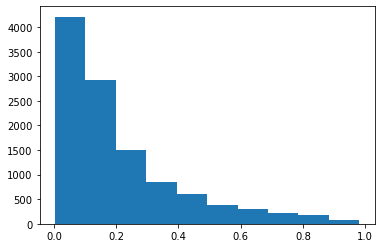

In [118]:
plt.hist(train_probs[:,1])

In [120]:
from sklearn.metrics import accuracy_score

In [121]:
accuracy_score(train_targets, train_preds)

0.8249777777777778

### Модель досягає точності 82,49% на навчальному наборі: непогано (?), але поки що не впевнена.

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

### Ми можемо візуалізувати розподіл правильно та неправильно класифікованих входів за допомогою матриці плутанини (confusion matrix)

In [122]:
from sklearn.metrics import confusion_matrix

In [123]:
confusion_matrix(train_targets, train_preds)

array([[8572,  412],
       [1557,  709]], dtype=int64)

In [126]:
import seaborn as sns

In [124]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 82.50%


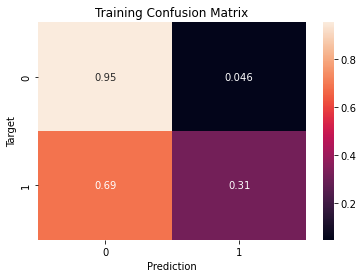

In [127]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 81.97%


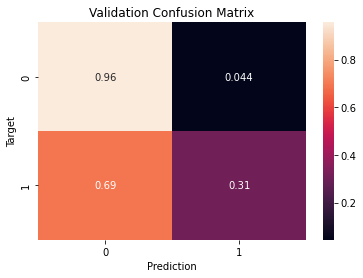

In [128]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

In [135]:
from sklearn.metrics import f1_score

In [136]:
preds = model.predict(X_train)
preds[:5], train_targets[:5]

(array([0., 0., 0., 0., 0.]),
 7410     0.0
 10894    0.0
 1934     0.0
 11539    0.0
 2952     0.0
 Name: Exited, dtype: float64)

In [139]:
f1_score(train_targets, preds)

0.4186595807499262

In [140]:
def get_f1_score(inputs, targets, name=''):
    preds = model.predict(inputs)
    
    f1_score_ = f1_score(targets, preds)
    print(f"F1 score {name}: {f1_score_:.2f}%")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')
#get_f1_score(X_test, test_targets, 'Test')

F1 score Training: 0.42%
F1 score Validation: 0.42%


In [143]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
    # Predict probabilities
    y_pred_proba = model.predict_proba(inputs)[:, 1]
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {roc_auc:.2f}')
    
    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc="lower right")
    plt.show()

AUROC for Training: 0.81


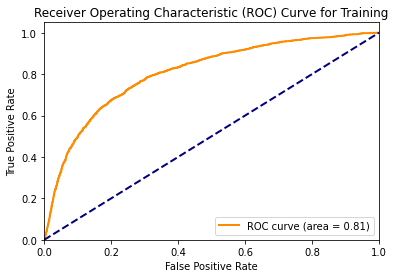

AUROC for Validation: 0.80


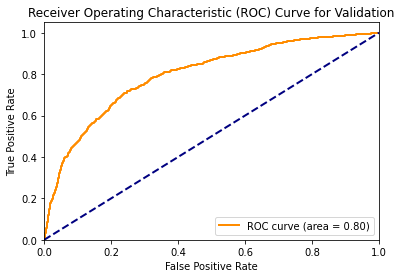

In [144]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

### Здається модель хороша, але я не впевнена чи правдоподібна вона. RОС майже однакова у Train і Val. Але є особливістю, що маємо дуже малий відсоток True Negatives TN (квадрант справа внизу, 31%), хороша модель повинна мати більший рівень.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [145]:
majority_class = y_train.mode()[0]
print(majority_class)

0.0


In [146]:
y_pred_train_baseline = np.full(len(y_train), majority_class)
y_pred_val_baseline = np.full(len(y_val), majority_class)

In [147]:
train_acc_baseline = accuracy_score(y_train, y_pred_train_baseline)
val_acc_baseline = accuracy_score(y_val, y_pred_val_baseline)

In [148]:
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

train_acc = accuracy_score(y_train, y_pred_train)
val_acc = accuracy_score(y_val, y_pred_val)

In [149]:
train_acc, val_acc

(0.8249777777777778, 0.8197333333333333)

### якість хороша або задовільна, бо схожий на Train.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [150]:
import joblib

In [155]:
log_reg = {
    'model': model,
    'scaler': scaler,
    'encoder_gender': encoder_gender,
    'encoder_geo': encoder_geo,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols
}

In [156]:
joblib.dump(log_reg, 'log_reg.joblib')

['log_reg.joblib']

In [157]:
model2 = joblib.load('log_reg.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [165]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder_gender, encoder_geo, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    
    encoded_gender_cols = list(encoder_gender.get_feature_names_out(["Gender"]))
    encoded_geo_cols = list(encoder_geo.get_feature_names_out(["Geography"]))
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_gender_cols] = encoder_gender.transform(input_df[["Gender"]])
    input_df[encoded_geo_cols] = encoder_geo.transform(input_df[["Geography"]])
    X_input = input_df[numeric_cols + encoded_gender_cols + encoded_geo_cols]

    
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [166]:
predict_raw_df(scaler, encoder_gender, encoder_geo, numeric_cols, categorical_cols, train_df_original[:5])

array([0.48928702, 0.48175034, 0.49219658, 0.50759503, 0.51698958])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [172]:
test_raw_df = pd.read_csv("test.csv")


In [174]:
test_raw_df["Exited"] = predict_raw_df(scaler, encoder_gender, encoder_geo, numeric_cols,categorical_cols, test_raw_df)

In [175]:
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain,Exited
0,15000,15594796.0,Chu,0.365155,Germany,Male,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,0.0,1.0,0.0,1.0,0.0,0.499065
1,15001,15642821.0,Mazzi,0.286396,France,Male,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,0.0,1.0,1.0,0.0,0.0,0.487665
2,15002,15716284.0,Onyekachi,0.656325,France,Male,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,0.0,1.0,1.0,0.0,0.0,0.496478
3,15003,15785078.0,Martin,0.682578,Spain,Male,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,1.0,0.0,0.0,1.0,0.490997
4,15004,15662955.0,Kenechukwu,0.384248,Spain,Male,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,1.0,0.0,0.0,1.0,0.480011


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [177]:
sample_submissions = pd.read_csv("sample_submission.csv")

In [178]:
sample_submissions["Exited"] = test_raw_df["Exited"]

In [179]:
sample_submissions.head()

,id,Exited
0,15000,0.499065
1,15001,0.487665
2,15002,0.496478
3,15003,0.490997
4,15004,0.480011


In [181]:
sample_submissions.to_csv("submission_log_reg.csv", index=False)